# AI/ML Task 2: Feature Engineering, Model Optimization & Performance Comparison

## Project Title
Enhanced House Price Prediction System

## Objective
The objective of this task is to improve a basic machine learning model by applying preprocessing techniques, training multiple regression algorithms, comparing their performance, and selecting the best-performing model.

## Dataset Used
The California Housing Dataset is used in this project.  
The target variable is Median House Value, renamed as HousePrice.

Input features include:
- Median Income
- House Age
- Average Rooms
- Average Bedrooms
- Population
- Average Occupancy
- Latitude
- Longitude

# Step 1: Import required libraries

In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

Matplotlib is building the font cache; this may take a moment.


## Step 2: Load the Dataset

The California Housing Dataset is loaded using scikit-learn.  
The dataset is converted into a pandas DataFrame, and the target column is renamed as HousePrice.

In [2]:
# Step 2: Load dataset

data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Dataset Inspection

In this step, we check the structure of the dataset, data types, and missing values to understand the quality of the data.

In [ ]:
# step 3: Check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Check missing values

df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

## Step 4: Separate Features and Target Variable

The input features are stored in X, and the output target variable HousePrice is stored in y.

In [ ]:
# step 4

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

## Step 5: Feature Scaling

Feature scaling is applied using StandardScaler.  
This ensures that all input features have a common scale and no feature dominates the model due to large numeric values.

In [ ]:
# Step 5: Feature scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 6: Train-Test Split

The dataset is divided into training and testing sets.  
80% of the data is used for training, and 20% is used for testing.

In [ ]:
# Step 6: Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## Step 7: Train Multiple Models

Three regression models are trained:
- Linear Regression
- Ridge Regression
- Decision Tree Regressor

Linear Regression is used as a baseline model.  
Ridge Regression helps reduce overfitting.  
Decision Tree Regressor captures non-linear relationships.

In [ ]:
# Step 7: Train multiple models

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

## Step 8: Model Evaluation and Comparison

The models are evaluated using:
- RMSE
- R2 Score

Lower RMSE means better prediction accuracy.  
Higher R2 Score means better model performance.

In [ ]:
# Step 8: Evaluate models

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


## Step 9: Best Model Selection

The model with the lowest RMSE is selected as the best-performing model.

In [ ]:
# Step 9: Select best model based on lowest RMSE

best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print(results_df.loc[best_model_name])

Best Model: Decision Tree
RMSE        0.724234
R2 Score    0.599732
Name: Decision Tree, dtype: float64


## Step 10: Visual Performance Validation

An Actual vs Predicted graph is plotted.  
If the points are closer to the reference line, the model predictions are better.

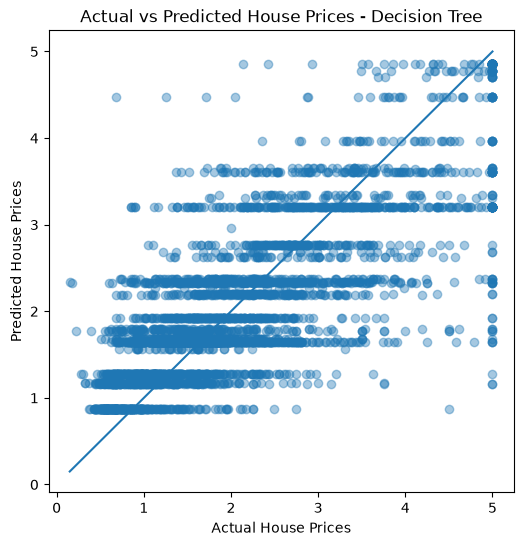

In [ ]:
# Step 10: Actual vs Predicted graph

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted House Prices - {best_model_name}")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

## Step 11: Save the Best Model

The best-performing model and scaler are saved using joblib so they can be reused later without retraining.

In [ ]:
# Step 11: Save best model and scaler

joblib.dump(best_model, "best_house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Best model and scaler saved successfully.")

Best model and scaler saved successfully.


In [ ]:
# Step 12: Test prediction with sample input

sample_data = pd.DataFrame([{
    "MedInc": 8.3252,
    "HouseAge": 41.0,
    "AveRooms": 6.984127,
    "AveBedrms": 1.023810,
    "Population": 322.0,
    "AveOccup": 2.555556,
    "Latitude": 37.88,
    "Longitude": -122.23
}])

sample_scaled = scaler.transform(sample_data)
predicted_price = best_model.predict(sample_scaled)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 4.778788739495789


## Conclusion

In this project, an enhanced House Price Prediction system was built using the California Housing Dataset.  
Feature scaling was applied to improve learning stability.  
Multiple models were trained and compared using RMSE and R2 Score.  
The best-performing model was selected based on evaluation metrics.  
This task helped understand a professional machine learning workflow involving preprocessing, model comparison, evaluation, and final model selection.